In [6]:
import os
import shutil
import random
import warnings
import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Image processing
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from skimage.io import imread
from skimage.transform import resize
import cv2
from skimage import measure

# Machine learning utilities
from sklearn.model_selection import train_test_split

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, MaxPooling2D,
    BatchNormalization, Activation, concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

warnings.filterwarnings("ignore")

In [7]:
input_dir = "../datasets/kaggle_3m"
output_images = "working/images"
output_masks = "working/masks"

os.makedirs(output_images, exist_ok=True)
os.makedirs(output_masks, exist_ok=True)

for case_folder in os.listdir(input_dir):
    case_path = os.path.join(input_dir, case_folder)
    if not os.path.isdir(case_path):
        continue

    for file in os.listdir(case_path):
        if file.endswith('.tif'):
            full_path = os.path.join(case_path, file)
            if '_mask' in file.lower():
                shutil.copy(full_path, os.path.join(output_masks, case_folder + '_' + file))
            else:
                shutil.copy(full_path, os.path.join(output_images, case_folder + '_' + file))

In [8]:
image_paths = sorted([os.path.join(output_images ,f) for f in os.listdir(output_images)]) 
mask_paths = sorted ([os.path.join(output_masks , f ) for f in os.listdir(output_masks)])
print("Total Images:", len(image_paths))
print("Total Masks:", len(mask_paths))

Total Images: 3929
Total Masks: 3929


In [12]:
def label(mask_path):
    """
    Return 1 if the mask image contains any non-zero pixel (tumor), else 0.
    """
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    return 1 if np.max(mask) > 0 else 0

# Build dataframe using existing lists `image_paths` and `mask_paths`
df = pd.DataFrame({
    "image_path": image_paths,
    "mask_path": mask_paths,
    "label": [label(m) for m in mask_paths]
})

df.head()

,image_path,mask_path,label
0,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,0
1,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,1
2,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,1
3,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,1
4,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,1


In [13]:
data = []
for img , msk in zip(image_paths ,mask_paths ):
    data.append({
        "image_path" : img,
        "mask_path" : msk,
        "image_name" : os.path.basename(img),
        "mask_name" : os.path.basename(msk)
    }
    )
df = pd.DataFrame(data)
df.head()

,image_path,mask_path,image_name,mask_name
0,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_1.tif,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_10...
1,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_10...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_11...
2,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_11...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_12...
3,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_12...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_13...
4,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_13...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_14...


In [14]:
tumor_status = []

for mask_path in tqdm.tqdm(df["mask_path"], desc="Checking masks"):
    mask = img_to_array(load_img(mask_path, color_mode="grayscale"))
    if np.max(mask) > 0:
        tumor_status.append("Tumor")
    else:
        tumor_status.append("Non-Tumor")

df["status"] = tumor_status
df.head()

Checking masks: 100%|██████████| 3929/3929 [00:01<00:00, 2193.30it/s]


,image_path,mask_path,image_name,mask_name,status
0,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_1.tif,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_10...,Non-Tumor
1,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_10...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_11...,Tumor
2,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_11...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_12...,Tumor
3,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_12...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_13...,Tumor
4,working/images\TCGA_CS_4941_19960909_TCGA_CS_4...,working/masks\TCGA_CS_4941_19960909_TCGA_CS_49...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_13...,TCGA_CS_4941_19960909_TCGA_CS_4941_19960909_14...,Tumor


In [15]:
counts = df["status"].value_counts()
print(counts)

status
Non-Tumor    2556
Tumor        1373
Name: count, dtype: int64


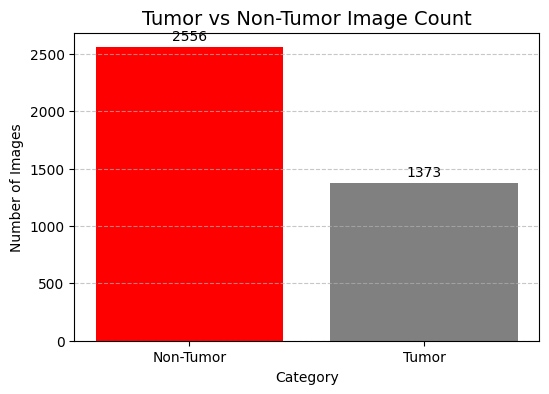

In [16]:
plt.figure(figsize=(6,4))
bars = plt.bar(counts.index, counts.values, color=["red", "gray"])
plt.title("Tumor vs Non-Tumor Image Count", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of Images")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.bar_label(bars, padding=3)
plt.show()

In [17]:
IMG_SIZE = 128   
def process_image(image_path, mask_path, img_size=IMG_SIZE):
    # Load image
    image = load_img(image_path, target_size=(img_size, img_size))
    image = img_to_array(image) / 255.0  # Normalize
    
    # Load mask (grayscale)
    mask = load_img(mask_path, target_size=(img_size, img_size), color_mode="grayscale")
    mask = img_to_array(mask)
    
    # Ensure mask is binary (0 or 1)
    mask = mask / 255.0
    mask = np.where(mask > 0.5, 1, 0)
    
    return image.astype(np.float32), mask.astype(np.float32)

In [18]:
images = []
masks = []

for img_path, msk_path in zip(image_paths, mask_paths):
    img, msk = process_image(img_path, msk_path)
    images.append(img)
    masks.append(msk)

images = np.array(images)
masks = np.array(masks)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Images shape: (3929, 128, 128, 3)
Masks shape: (3929, 128, 128, 1)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)

Train: (3143, 128, 128, 3) (3143, 128, 128, 1)
Test:  (786, 128, 128, 3) (786, 128, 128, 1)


In [20]:
def visualize_samples(images, masks, n_samples=4):
    """
    Show random tumor and non-tumor MRI images with their masks.
    """
    tumor_indices = []
    non_tumor_indices = []

    # Separate indices for tumor and non-tumor
    for i in range(len(masks)):
        if np.max(masks[i]) > 0:      # Tumor present
            tumor_indices.append(i)
        else:                         # No tumor
            non_tumor_indices.append(i)

    # Choose random samples
    tumor_samples = random.sample(tumor_indices, min(n_samples, len(tumor_indices)))
    non_tumor_samples = random.sample(non_tumor_indices, min(n_samples, len(non_tumor_indices)))

    # Plot
    plt.figure(figsize=(12, 8))
    for i, idx in enumerate(tumor_samples):
        plt.subplot(2, n_samples, i+1)
        plt.imshow(images[idx])
        plt.imshow(masks[idx].squeeze(), cmap="Reds", alpha=0.4)
        plt.title("Tumor")
        plt.axis("off")

    for i, idx in enumerate(non_tumor_samples):
        plt.subplot(2, n_samples, i + 1 + n_samples)
        plt.imshow(images[idx])
        plt.imshow(masks[idx].squeeze(), cmap="Reds", alpha=0.3)
        plt.title("No Tumor")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [21]:
def unet(input_size = (256,256,3)):
    inputs = Input(input_size)
    conv1 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(inputs)
    conv1 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool1)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    
    conv4 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool3)
    conv4 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv4)
    drop4 = Dropout(0.5)(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop4)

    conv5 = Conv2D(1024, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool4)
    conv5 = Conv2D(1024, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv5)
    drop5 = Dropout(0.5)(conv5)

    up6 = Conv2D(512, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(drop5))
    
    merge6 = concatenate([drop4,up6], axis = 3)
    conv6 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge6)
    conv6 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv6)

    up7 = Conv2D(256, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv6))
    merge7 = concatenate([conv3,up7], axis = 3)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge7)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv7)

    up8 = Conv2D(128, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv7))
    merge8 = concatenate([conv2,up8], axis = 3)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge8)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv8)

    up9 = Conv2D(64, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv8))
    merge9 = concatenate([conv1,up9], axis = 3)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge9)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv9)
    conv10 = Conv2D(1, 1, activation = 'sigmoid')(conv9)

    model = Model(inputs= inputs, outputs = conv10)
    return model

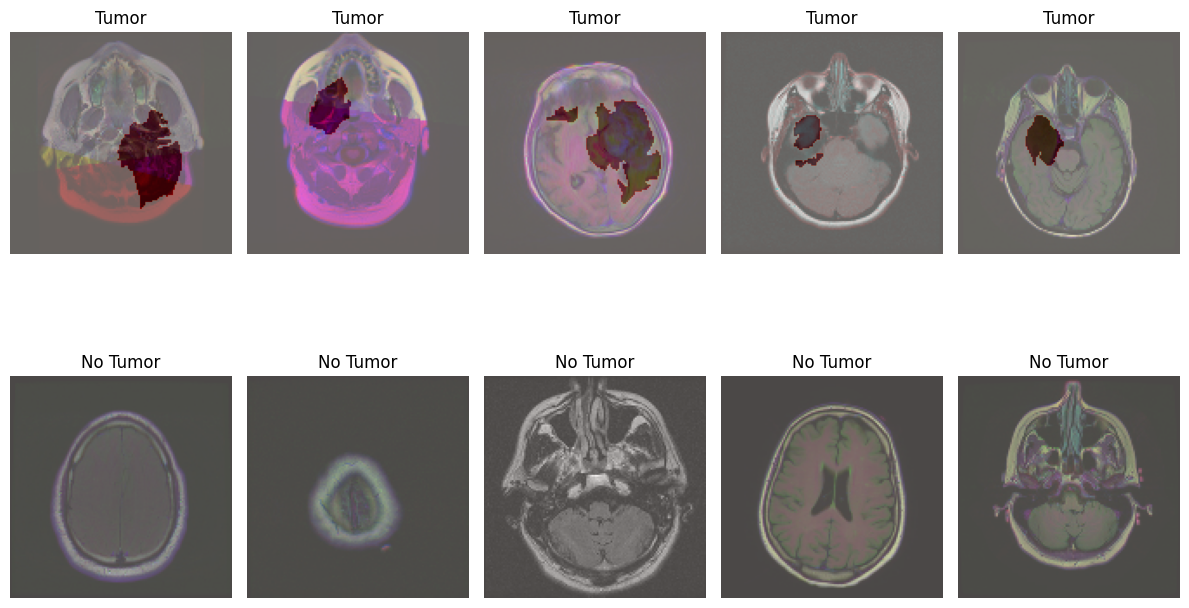

In [22]:
visualize_samples(X_test, y_test, n_samples=5)

In [23]:
# Augmentation configurations
data_gen_args = dict(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create ImageDataGenerator for both images and masks
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

# Same seed to ensure images and masks are augmented equally
seed = 42
batch_size = 16

image_generator = image_datagen.flow(X_train, batch_size=batch_size, seed=seed)
mask_generator = mask_datagen.flow(y_train, batch_size=batch_size, seed=seed)

In [24]:
def train_gen(image_gen, mask_gen):
    while True:
        img_batch = next(image_gen)
        mask_batch = next(mask_gen)

        yield (img_batch, mask_batch)

train_generator = train_gen(image_generator, mask_generator)

In [25]:
def conv_block(x, filters, kernel_size=3, batch_norm=True, dropout=0.0):
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(filters, kernel_size, padding='same', kernel_initializer='he_normal')(x)
    if batch_norm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    if dropout and dropout > 0.0:
        x = layers.Dropout(dropout)(x)
    return x

def encoder_block(x, filters, pool=True, pool_size=(2,2), dropout=0.0):
    c = conv_block(x, filters, dropout=dropout)
    if pool:
        p = layers.MaxPooling2D(pool_size)(c)
        return c, p
    else:
        return c

def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, (2,2), strides=(2,2), padding='same')(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), out_channels=1, base_filters=32, dropout_rate=0.1):
    inputs = layers.Input(shape=input_shape)
    
    # Encoder
    c1, p1 = encoder_block(inputs, base_filters, pool=True, dropout=dropout_rate)      # 32
    c2, p2 = encoder_block(p1, base_filters*2, pool=True, dropout=dropout_rate)        # 64
    c3, p3 = encoder_block(p2, base_filters*4, pool=True, dropout=dropout_rate)        # 128
    c4, p4 = encoder_block(p3, base_filters*8, pool=True, dropout=dropout_rate)        # 256
    
    # Bottleneck
    b = conv_block(p4, base_filters*16, batch_norm=True, dropout=dropout_rate)         # 512

    # Decoder
    d1 = decoder_block(b, c4, base_filters*8)
    d2 = decoder_block(d1, c3, base_filters*4)
    d3 = decoder_block(d2, c2, base_filters*2)
    d4 = decoder_block(d3, c1, base_filters)
    
    # Output
    if out_channels == 1:
        outputs = layers.Conv2D(1, (1,1), activation='sigmoid')(d4)
    else:
        outputs = layers.Conv2D(out_channels, (1,1), activation='softmax')(d4)
    
    model = Model(inputs, outputs, name='UNet_Professional')
    return model


model = build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), out_channels=1, base_filters=32, dropout_rate=0.1)
model.summary()

Model: "UNet_Professional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ dropout_1[0][0] 

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [26]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dl = dice_loss(y_true, y_pred)
    return bce + dl

def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]), tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    total = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    union = total - intersection
    return (intersection + smooth) / (union + smooth)

In [27]:
#  Compile Model
LEARNING_RATE = 1e-4
model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
              loss=bce_dice_loss,
              metrics=[dice_coef, iou_coef, 'accuracy'])

In [29]:
#  Callbacks
checkpoint_path = "/working/checkpoints/unet_best.keras"
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss', mode='min', verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

In [30]:
#  Train Model with Augmentation
steps_per_epoch = len(X_train) // batch_size

history = model.fit(
    train_generator,
    validation_data=(X_test, y_test),
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5888 - dice_coef: 0.0272 - iou_coef: 0.0138 - loss: 1.6804
Epoch 1: val_loss improved from inf to 1.40094, saving model to /working/checkpoints/unet_best.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.5899 - dice_coef: 0.0272 - iou_coef: 0.0139 - loss: 1.6793 - val_accuracy: 0.9891 - val_dice_coef: 0.0230 - val_iou_coef: 0.0117 - val_loss: 1.4009 - learning_rate: 1.0000e-04
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9885 - dice_coef: 0.0450 - iou_coef: 0.0232 - loss: 1.2439
Epoch 2: val_loss improved from 1.40094 to 1.21673, saving model to /working/checkpoints/unet_best.keras
196/196 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.9885 - dice_coef: 0.0451 - iou_coef: 0.0232 - loss: 1.2438 - val_accuracy: 0.9912 - val_dice_coef: 0.0423 - val_iou_coef: 0.0217 - val_loss: 1.2167 - learning_rate: 1.0000e-04
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9879 - dice_coef:

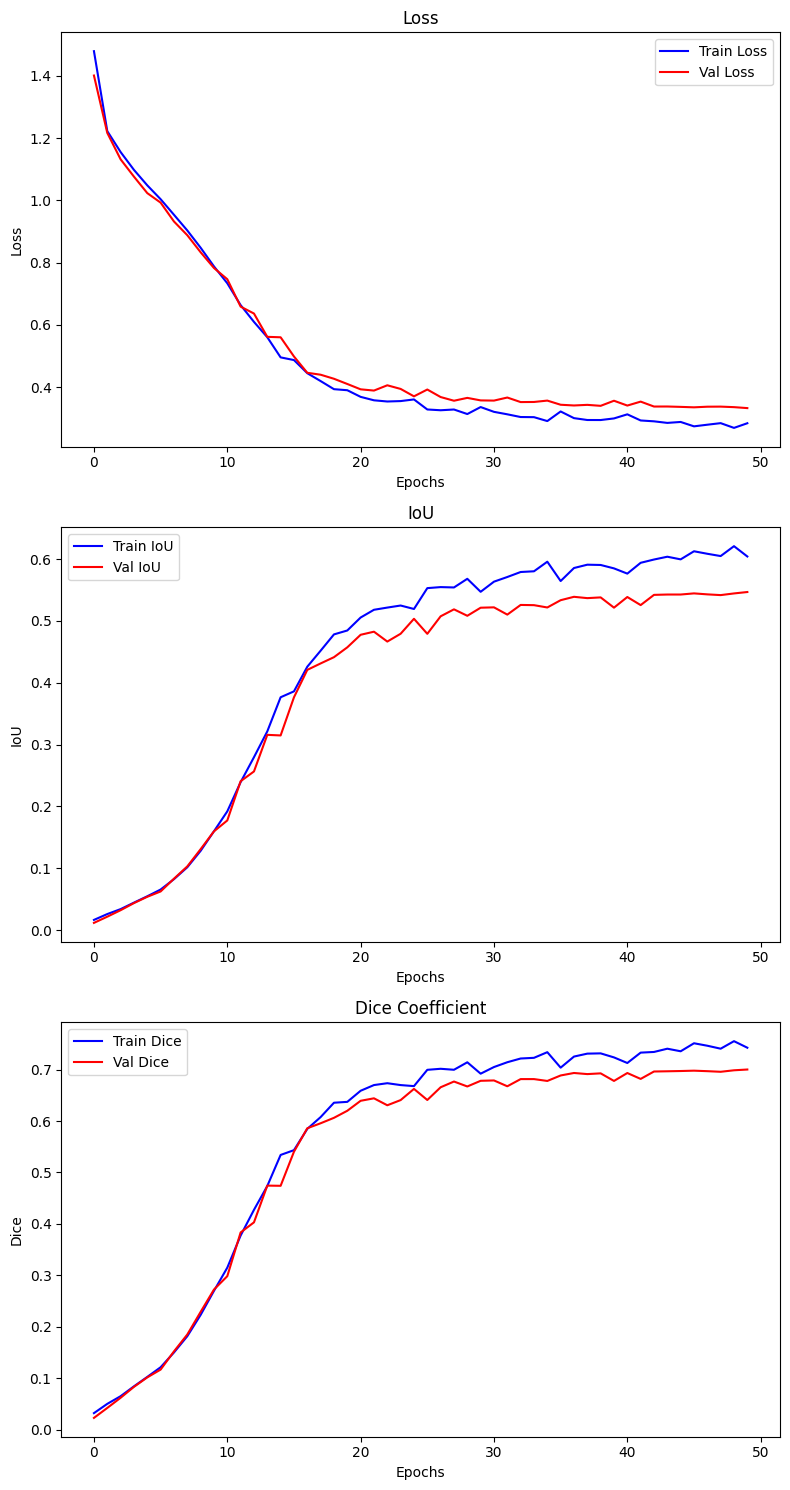

In [31]:
# Evaluation Visualization
plt.figure(figsize=(8, 15))

# --- Loss ---
plt.subplot(3, 1, 1)
plt.plot(history.history['loss'], 'b-', label='Train Loss')
plt.plot(history.history['val_loss'], 'r-', label='Val Loss')
plt.legend(loc='best')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

# --- IoU ---
plt.subplot(3, 1, 2)
plt.plot(history.history['iou_coef'], 'b-', label='Train IoU')
plt.plot(history.history['val_iou_coef'], 'r-', label='Val IoU')
plt.legend(loc='best')
plt.title('IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')

# --- Dice Coefficient ---
plt.subplot(3, 1, 3)
plt.plot(history.history['dice_coef'], 'b-', label='Train Dice')
plt.plot(history.history['val_dice_coef'], 'r-', label='Val Dice')
plt.legend(loc='best')
plt.title('Dice Coefficient')
plt.xlabel('Epochs')
plt.ylabel('Dice')

plt.tight_layout()
plt.show()

In [32]:
BATCH_SIZE=16
# Define test data generator (no augmentation)
test_datagen = ImageDataGenerator()

# Create generator for test data
test_generator = test_datagen.flow(
    X_test, 
    y_test, 
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Evaluate model
results = model.evaluate(test_generator, steps=len(X_test) // BATCH_SIZE)

print(f" Test Loss: {results[0]:.4f}")
print(f" Test Dice Coefficient: {results[1]:.4f}")
print(f" Test IoU: {results[2]:.4f}")
print(f" Test Accuracy: {results[3]:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 12s 253ms/step - accuracy: 0.9948 - dice_coef: 0.7171 - iou_coef: 0.5791 - loss: 0.3128
 Test Loss: 0.3399
 Test Dice Coefficient: 0.6927
 Test IoU: 0.5484
 Test Accuracy: 0.9945


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


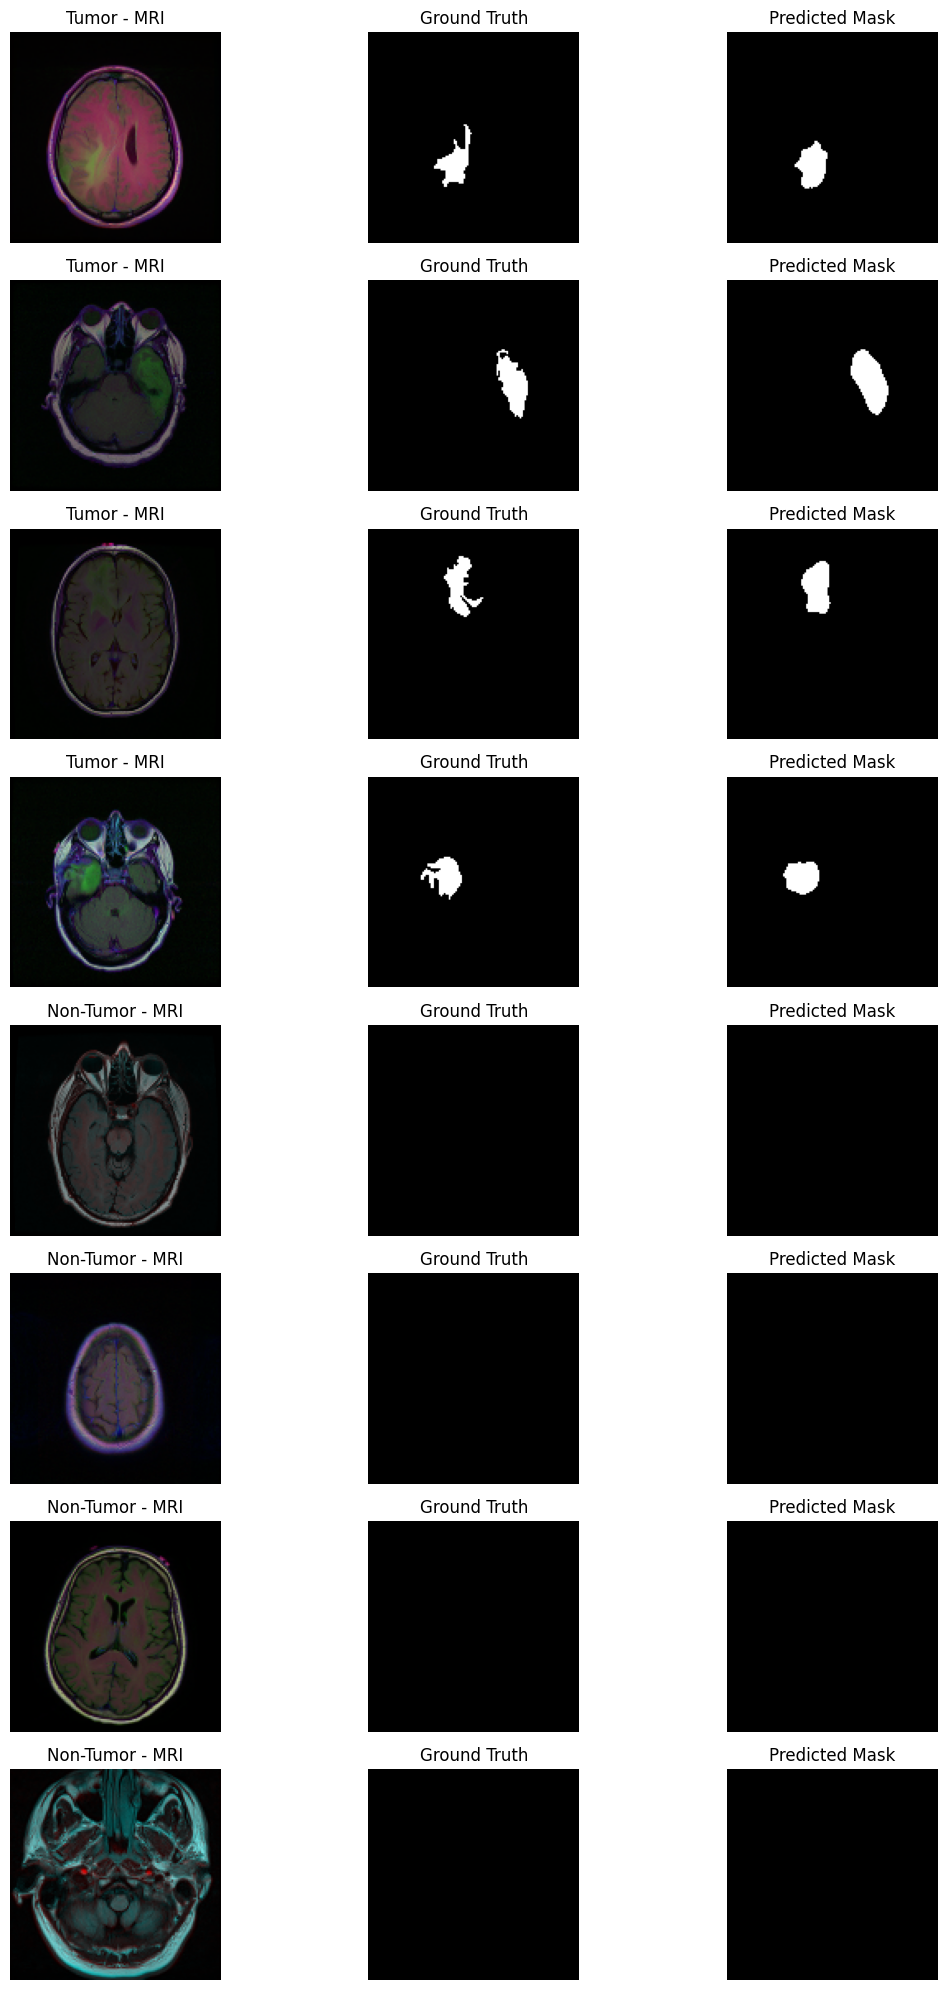

In [33]:
def visualize_predictions(model, X_test, y_test, num_per_class=4):
    """
    Visualize a balanced set of tumor and non-tumor samples with 
    original MRI, ground truth mask, and predicted mask.
    """
    # Flatten masks to detect presence of tumor (any pixel > 0)
    tumor_indices = [i for i in range(len(y_test)) if np.any(y_test[i] > 0)]
    non_tumor_indices = [i for i in range(len(y_test)) if not np.any(y_test[i] > 0)]

    # Ensure enough samples exist in both categories
    tumor_indices = random.sample(tumor_indices, min(num_per_class, len(tumor_indices)))
    non_tumor_indices = random.sample(non_tumor_indices, min(num_per_class, len(non_tumor_indices)))

    selected_indices = tumor_indices + non_tumor_indices
    total_samples = len(selected_indices)

    plt.figure(figsize=(12, total_samples * 2.5))

    for i, idx in enumerate(selected_indices):
        image = X_test[idx]
        true_mask = y_test[idx]

        # Predict mask
        pred_mask = model.predict(np.expand_dims(image, axis=0))[0]
        pred_mask = (pred_mask > 0.5).astype(np.uint8)

        # Titles
        label = "Tumor" if np.any(true_mask > 0) else "Non-Tumor"

        # Original MRI
        plt.subplot(total_samples, 3, i*3 + 1)
        plt.imshow(image)
        plt.title(f"{label} - MRI")
        plt.axis("off")

        # Ground truth mask
        plt.subplot(total_samples, 3, i*3 + 2)
        plt.imshow(true_mask.squeeze(), cmap='gray')
        plt.title("Ground Truth")
        plt.axis("off")

        # Predicted mask
        plt.subplot(total_samples, 3, i*3 + 3)
        plt.imshow(pred_mask.squeeze(), cmap='gray')
        plt.title("Predicted Mask")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Run visualization 
visualize_predictions(model, X_test, y_test, num_per_class=4)